In [90]:
from jqdata import *
from jqfactor import *
import jqdata
from jqfactor import *
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import jqdata
from jqfactor import *
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pandas.tseries.offsets import CustomBusinessDay
import datetime
import xgboost as xgb
import lightgbm as lgb
import talib
from sklearn.preprocessing import StandardScaler         
from sklearn.preprocessing import MinMaxScaler
current_date = datetime.datetime.now()
# List = ['518880.XSHG','513100.XSHG','513030.XSHG','513880.XSHG','164824.XSHE','161129.XSHE']
List = ['518880.XSHG','513100.XSHG','513030.XSHG','513500.XSHG']
current_time = current_date.strftime("%Y-%m-%d")


def get_period_date(peroid,start_date, end_date):
    #设定转换周期period_type  转换为周是'W',月'M',季度线'Q',五分钟'5min',12天'12D'
    stock_data = get_price('000001.XSHG',start_date,end_date,'daily',fields=['close'])
    #记录每个周期中最后一个交易日
    stock_data['date']=stock_data.index
    #进行转换，周线的每个变量都等于那一周中最后一个交易日的变量值
    period_stock_data=stock_data.resample(peroid,how='last')
    period_stock_data = period_stock_data.set_index('date').dropna()
    date=period_stock_data.index
    pydate_array = date.to_pydatetime()
    date_only_array = np.vectorize(lambda s: s.strftime('%Y-%m-%d'))(pydate_array )
    date_only_series = pd.Series(date_only_array)
    start_date = datetime.datetime.strptime(start_date, "%Y-%m-%d")
    start_date=start_date-datetime.timedelta(days=1)
    start_date = start_date.strftime("%Y-%m-%d")
    date_list=date_only_series.values.tolist()
    date_list.insert(0,start_date)
    return date_list

peroid = 'D'
start_date = '2015-01-01'
# start_date = '2023-01-01'
end_date = current_time


DAY = get_period_date(peroid,start_date, end_date)
print(len(DAY))


2190


In [91]:

train_data=[]
for date in tqdm(DAY):    
    factor_data = get_price(List,  frequency='1d', 
                count=1, \
               end_date=date,
#                fields=['open','close','high','low']
              )


    df_jq_factor=pd.DataFrame(index=List)

    for i in factor_data.keys():
        df_jq_factor[i]=factor_data[i].iloc[0,:]
#     columns_list = df_jq_factor.columns.tolist()
#     scaler = MinMaxScaler() #MinMaxScaler()  StandardScaler()
#     df_normalized = pd.DataFrame(scaler.fit_transform(df_jq_factor), columns=columns_list)

    data = np.array(df_jq_factor)
    train_data.append(data.reshape(-1))
train_data = np.array(train_data)

    

100%|██████████| 2190/2190 [00:31<00:00, 69.52it/s]


In [92]:

df = get_price('000001.XSHG',  frequency='1d', 
                count=len(DAY), \
               end_date=current_time,
#                fields=['open','close','high','low']
              )

# df = df.dropna()
today = datetime.datetime.today()
date_str = today.strftime("%Y%m%d")
base = int(datetime.datetime.strptime(date_str, "%Y%m%d").timestamp())
change1 = lambda x: (int(datetime.datetime.strptime(x, "%Y%m%d").timestamp()) - base) / 86400
change2 = lambda x: (datetime.datetime.strptime(str(x), "%Y%m%d")).day
change3 = lambda x: datetime.datetime.strptime(str(x), "%Y%m%d").strftime("%j")
df['date'] = df.index.astype(str)
df['date'] = df['date'].str.replace('-', '')
X = df['date'].apply(lambda x: change1(x)).values.reshape(-1, 1)
X_month_day = df['date'].apply(lambda x: change2(x)).values.reshape(-1, 1)
X_week_day = df['date'].apply(lambda x: change3(x)).values.reshape(-1, 1)
XX = np.concatenate((X, X_week_day,X_month_day), axis=1)[45:]
FT = np.array(df.drop(columns=['date']))

window_size = 46
num_rows, num_columns = FT.shape
new_num_rows = num_rows - window_size + 1
result1 = np.empty((new_num_rows, num_columns))
result2 = np.empty((new_num_rows, num_columns))
result3 = np.empty((new_num_rows, num_columns))
result4 = np.empty((new_num_rows, num_columns))
result5 = np.empty((new_num_rows, num_columns))
for i in range(new_num_rows):
    window = FT[i: i + window_size]
#     print(window.shape)
#     scaler = StandardScaler() #MinMaxScaler()
#     window = scaler.fit_transform(window)
    # 求平均值
    result1[i] = np.mean(window, axis=0)
    # 求最大值
    result2[i] = np.max(window, axis=0)
    # 求最小值
    result3[i] = np.min(window, axis=0)
    # 求标准差
    result4[i] = np.std(window, axis=0)
    # 求方差
    result5[i] = np.var(window, axis=0)

data=train_data[45:,:]
print(data.shape)
result_list = [result1, result2, result3, result4, result5,data]
result = np.hstack(result_list)
print(result.shape)
print(result[0])


(2145, 24)
(2145, 54)
[3248.9593478260863 3258.2710869565217 3290.068695652174 3219.205217391304
 31001609323.913044 349653134334.56525 3389.85 3383.18 3406.79 3352.15
 53135239100.0 549760106398.0 3063.51 3075.91 3119.03 3049.11
 17284009400.0 210862549367.0 78.14314104931366 81.66705253991755
 77.64334853811833 77.61864594841744 7633102306.875726 79006566448.20416
 6106.350493052928 6669.507470557653 6028.489572211723 6024.654198865779
 5.826425082723153e+19 6.242037541934501e+21 2.368 2.359 2.368 2.357
 40918000.0 96646456.0 0.288 0.286 0.288 0.285 1017848645.0 291570880.0
 0.998 1.003 1.006 0.998 17222731.0 17251684.0 0.59 0.582 0.59 0.581
 343021679.0 200237316.0]


(5, 57)


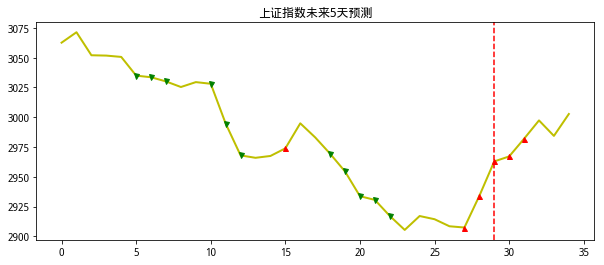

In [93]:

# scaler = StandardScaler()  

# result = scaler.fit_transform(result)  


XXx = np.concatenate((XX, result), axis=1)

models1 = {}



models1 = [None] * 5

# 循环训练模型
for i in range(5):
    # 创建 LightGBM 数据集
    if i > 0:
        y = (df['open'][45:].iloc[i:] + df['close'][45:].iloc[i:]) / 2
        train_data = lgb.Dataset(XXx[:-i], label=y)
    else:
        y = (df['open'][45:] + df['close'][45:]) / 2
        train_data = lgb.Dataset(XXx, label=y)
    # 设置 LightGBM 参数
    params = {
        'objective': 'regression',  # 回归任务
        'metric': 'mse',            # 评估指标为均方误差
        'num_leaves': 31,           # 树上的叶子节点数
        'learning_rate': 0.05,      # 学习率
        'feature_fraction': 0.9,    # 每次迭代中随机选择特征的比例
    }
        # 创建并训练模型
    num_round = 100  # 迭代轮数
    models1[i] = lgb.train(params, train_data, num_round)
    



Y_date = get_trade_days(start_date=current_date, count=5)
future = []
for i in Y_date:
    future.append(i.strftime('%Y-%m-%d'))

future_dates_str = pd.Series(future).str.replace('-', '')
X_x = future_dates_str.apply(lambda x: change1(x)).values.reshape(-1, 1)
X_month_day_x = future_dates_str.apply(lambda x: change2(x)).values.reshape(-1, 1)
X_week_day_x = future_dates_str.apply(lambda x: change3(x)).values.reshape(-1, 1)
XXX = np.concatenate((X_x, X_week_day_x, X_month_day_x), axis=1)
last_column = result[-1:, ]
repeated_last_column = np.tile(last_column, (5, 1))
Result = repeated_last_column

XXX = np.concatenate((XXX, Result), axis=1)

R1=[]
R2=[]
print(XXX.shape)

for i in range(5):
    pred1 = models1[i].predict(XXX[i].reshape(1, -1))
    R1.append(pred1)


Y0 = np.array(df['date'][-30:])
y1 = (np.array(df['open'][-30:])+np.array(df['close'][-30:]))/2




data = {
    'date': np.concatenate([Y0, np.array(future_dates_str)]),
    'predict_price': np.concatenate([y1, np.squeeze(np.array(R1))]),
}

dff = pd.DataFrame(data)

def detect_via_cusum_lg(ts, istart=30, threshold_times=5):
    S_h = 0
    S_l = 0
    S_list = np.zeros(istart)
    for i in range(istart+1, len(ts)-1):
        meanArray = talib.SMA(ts[i-istart:i],timeperiod = istart) #计算istart时间至今均线
        stdArray = talib.STDDEV(np.log(ts[i-istart:i]/meanArray[- 1]))#计算istart时间至今对数收益率的标准差。
        #滑窗至i，避免读到未来数据[i-istart:i]
        tslog = np.log(ts[i] / meanArray[- 1])
        #计算当前时点相对于历史时间序列的均值的对数收益率
        S_h_ = max(0, S_h + tslog - stdArray[-1])
        S_l_ = min(0, S_l + tslog + stdArray[-1])
        #计算上下边界
        if S_h_> threshold_times * stdArray[-1]: #上边界超过了设定的阈值（threshold_times倍的历史标准差）
            S_list = np.append(S_list,1) #上升
        elif abs(S_l_)> threshold_times *  stdArray[-1]:#下边界绝对值超过了设定的阈值（threshold_times倍的历史标准差）
            S_list = np.append(S_list, -1)
        else:
            S_list = np.append(S_list, 0) #如果上下边界都没有超过阈值，则在 S_list 中追加值 0，表示无信号。没变点
    return S_list

dt0 = np.array(dff["predict_price"])

listup,listdown = [],[]
s_list = detect_via_cusum_lg(dt0,istart=5, threshold_times=0.1)
for i in range(0,len(s_list)):
    if s_list[i] == 1:
        listup.append(i)
    elif s_list[i] == -1 :
        listdown.append(i)
plt.figure(figsize=(10, 4))
plt.plot(dt0, color='y', lw=2.)
plt.plot(dt0, '^', markersize=5, color='r', label='UP signal', markevery=listup)
plt.plot(dt0, 'v', markersize=5, color='g', label='DOWN signal', markevery=listdown)
plt.axvline(x=29, color='r', linestyle='--')
#线后面是未来预测
plt.title('上证指数未来5天预测')
plt.show()

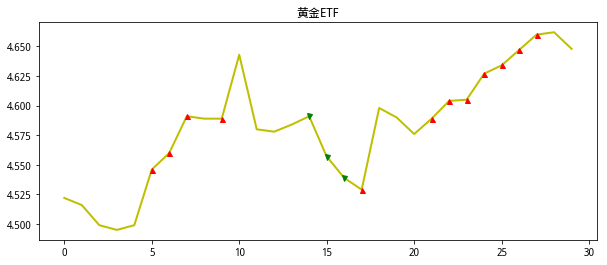

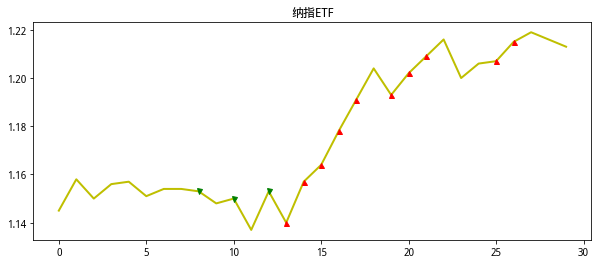

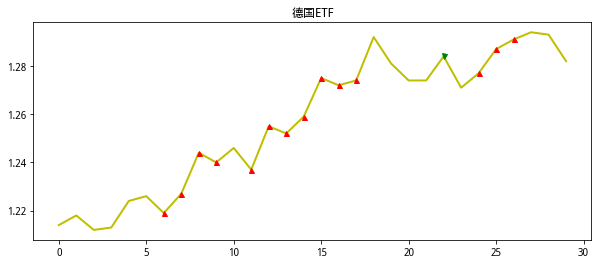

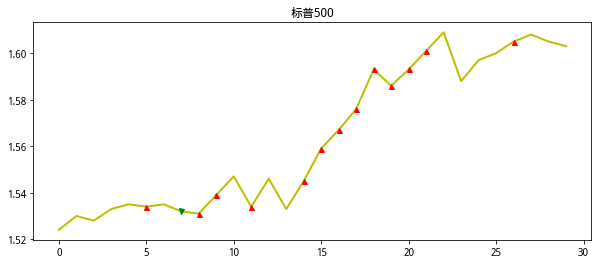

In [94]:
for i in List:
    name = get_security_info(i).display_name
    dt1 = get_price(i,  frequency='1d', 
                    count=30, \
                   end_date=current_time,
                   fields=['close']
                  )
    dt1 = np.array(dt1['close'])
    listup,listdown = [],[]
    s_list = detect_via_cusum_lg(dt1,istart=5, threshold_times=0.1)
    for i in range(0,len(s_list)):
        if s_list[i] == 1:
            listup.append(i)
        elif s_list[i] == -1 :
            listdown.append(i)
    plt.figure(figsize=(10, 4))
    plt.plot(dt1, color='y', lw=2.)
    plt.plot(dt1, '^', markersize=5, color='r', label='UP signal', markevery=listup)
    plt.plot(dt1, 'v', markersize=5, color='g', label='DOWN signal', markevery=listdown)
    plt.title(fr'{name}')
    plt.show()